In [2]:
from huggingface_hub import notebook_login

notebook_login()


In [23]:
import os
import shutil

# 1. Check current usage
print("--- 💾 Disk Usage BEFORE Cleaning ---")
!df -h /home/studio-lab-user

# 2. Define heavy folders to delete
# These are the caches from Exo, HuggingFace, and your failed Kaggle download
folders_to_clean = [
    "/home/studio-lab-user/.exo_cache",          # The Llama/Exo models
    "/home/studio-lab-user/.cache/kagglehub",    # The failed download (partial)
    "/home/studio-lab-user/.cache/huggingface",  # Other HF models
    "medgemma-finetuned"                         # Your finetuning checkpoints
]

print("\n--- 🧹 Cleaning up... ---")
for folder in folders_to_clean:
    if os.path.exists(folder):
        try:
            print(f"Deleting: {folder}...")
            shutil.rmtree(folder)
        except Exception as e:
            print(f"Error deleting {folder}: {e}")
    else:
        print(f"Already clean: {folder}")

# 3. Check space again
print("\n--- 💾 Disk Usage AFTER Cleaning ---")
!df -h /home/studio-lab-user

--- 💾 Disk Usage BEFORE Cleaning ---
The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.
Filesystem      Size  Used Avail Use% Mounted on
/dev/nvme2n1     25G   25G  176K 100% /home/studio-lab-user

--- 🧹 Cleaning up... ---
Deleting: /home/studio-lab-user/.exo_cache...
Deleting: /home/studio-lab-user/.cache/kagglehub...
Deleting: /home/studio-lab-user/.cache/huggingface...
Already clean: medgemma-finetuned

--- 💾 Disk Usage AFTER Cleaning ---
Filesystem      Size  Used Avail Use% Mounted on
/dev/nvme2n1     25G   13G   13G  51% /home/studio-lab-user


In [24]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

100%|██████████| 2.29G/2.29G [00:20<00:00, 122MB/s] 

Extracting files...


Path to dataset files: /home/studio-lab-user/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2


In [8]:
import os
import signal
import subprocess

# 1. Kill any background 'exo' processes from previous steps
try:
    subprocess.run(["pkill", "-f", "exo"], check=False)
    print("✅ Killed background Exo processes.")
except Exception:
    pass

# 2. Force garbage collection in Python
import gc
import torch
gc.collect()
torch.cuda.empty_cache()

# 3. Check memory
print(f"✅ GPU Memory Cleared.")
print(f"Free memory: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GB")

✅ Killed background Exo processes.
✅ GPU Memory Cleared.
Free memory: 6.39 GB


In [2]:
!nvidia-smi

Fri Jan 16 13:03:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.163.01             Driver Version: 550.163.01     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   28C    P0             25W /   70W |   10915MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [15]:
import torch
import gc

# --- STEP 1: THE CLEANUP ---
# Check if 'pipe' or 'model' exists in global memory and destroy them
if "pipe" in globals():
    del pipe
if "model" in globals():
    del model
if "processor" in globals():
    del processor

# Force Python's Garbage Collector to take out the trash
gc.collect()

# Tell PyTorch to release the VRAM explicitly
torch.cuda.empty_cache()

# Optional: Print status to confirm it worked
free_mem = torch.cuda.mem_get_info()[0] / 1024**3
print(f"🧹 GPU cleaned. Free memory: {free_mem:.2f} GB")

🧹 GPU cleaned. Free memory: 14.42 GB


In [16]:
from transformers import pipeline
from PIL import Image
import requests
import torch
# import os
# import signal
# import subprocess

# # 1. Kill any background 'exo' processes from previous steps
# try:
#     subprocess.run(["pkill", "-f", "exo"], check=False)
#     print("✅ Killed background Exo processes.")
# except Exception:
#     pass

# # 2. Force garbage collection in Python
# import gc
# import torch
# gc.collect()
# torch.cuda.empty_cache()

# # 3. Check memory
print(f"✅ GPU Memory Cleared.")
print(f"Free memory: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GB")
pipe = pipeline(
    "image-text-to-text",
    model="google/medgemma-1.5-4b-it",
    torch_dtype=torch.bfloat16,
    device="cuda",
)
image_path = "images/pne/person96_bacteria_464.jpeg"
# Image attribution: Stillwaterising, CC0, via Wikimedia Commons
image = Image.open(image_path)



✅ Killed background Exo processes.
✅ GPU Memory Cleared.
Free memory: 14.42 GB


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 8e94989c-d678-4e33-bdc8-4bb72d362d80)')' thrown while requesting HEAD https://huggingface.co/google/medgemma-1.5-4b-it/resolve/main/processor_config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: c915104c-3e68-4ad6-81bf-dd56dc22a17d)')' thrown while requesting HEAD https://huggingface.co/google/medgemma-1.5-4b-it/resolve/main/processor_config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: e19d8aea-b311-4735-878a-28964420b23f)')' thrown while requesting HEAD https://huggingface.co/google/medgemma-1.5-4b-it/resolve/main/processor_config.json
Retrying in 1s [Retry 1/5].
Device set to use cuda


📂 Dataset Root: /home/studio-lab-user/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray
   -> TRAIN: 1341 Normal, 3875 Pneumonia
   -> TEST: 234 Normal, 390 Pneumonia
   -> VAL: 8 Normal, 8 Pneumonia

--- 🩻 Random NORMAL X-Ray ---


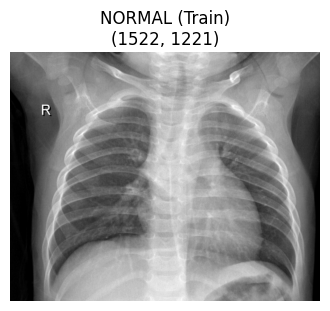


--- 🦠 Random PNEUMONIA X-Ray ---


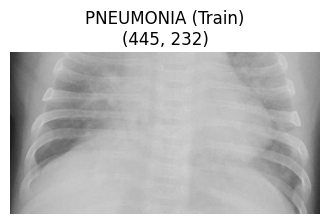

In [25]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import random

# 1. Point to the path from your output
cache_path = Path("/home/studio-lab-user/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2")

# 2. Fix Double-Nesting (Common in this dataset)
# Sometimes it extracts as '.../versions/2/chest_xray/chest_xray/train'
if (cache_path / "chest_xray").exists():
    root_dir = cache_path / "chest_xray"
else:
    root_dir = cache_path

print(f"📂 Dataset Root: {root_dir}")

# 3. Define the Splits
train_dir = root_dir / "train"
test_dir = root_dir / "test"
val_dir = root_dir / "val"

# 4. Check contents
for folder in [train_dir, test_dir, val_dir]:
    if folder.exists():
        normal_count = len(list((folder / "NORMAL").glob("*.jpeg")))
        pneumonia_count = len(list((folder / "PNEUMONIA").glob("*.jpeg")))
        print(f"   -> {folder.name.upper()}: {normal_count} Normal, {pneumonia_count} Pneumonia")
    else:
        print(f"   -> {folder.name.upper()}: ❌ Not found (Check path!)")

# 5. Visualize Samples
def show_sample(category):
    folder = train_dir / category
    images = list(folder.glob("*.jpeg"))
    
    if not images:
        return
    
    img_path = random.choice(images)
    img = Image.open(img_path)
    
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.title(f"{category} (Train)\n{img.size}")
    plt.axis('off')
    plt.show()

print("\n--- 🩻 Random NORMAL X-Ray ---")
show_sample("NORMAL")

print("\n--- 🦠 Random PNEUMONIA X-Ray ---")
show_sample("PNEUMONIA")

In [28]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Define Transforms (Resize is crucial for MedGemma/CNNs)
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Resize to standard input size
    transforms.ToTensor(),
])

# 2. Create the Dataset Object
# ImageFolder expects the structure: root/class_name/image.jpg
train_dataset = datasets.ImageFolder(root=train_dir, transform=data_transforms)

# 3. Create the Loader (Batches)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 4. Test it
images, labels = next(iter(train_loader))
print(f"✅ Batch Shape: {images.shape}") # Should be [32, 3, 224, 224]
print(f"✅ Classes: {train_dataset.classes}") # Should be ['NORMAL', 'PNEUMONIA']

✅ Batch Shape: torch.Size([32, 3, 224, 224])
✅ Classes: ['NORMAL', 'PNEUMONIA']


In [29]:
import pandas as pd
import random
from pathlib import Path

# --- 1. Setup Data Paths (Using the downloaded data) ---
# Ensure this matches the 'root_dir' we found in the previous step
test_dir = root_dir / "test" 

# Helper to get file paths
def get_image_paths(category, limit=3):
    folder = test_dir / category
    # Get all .jpeg files
    files = list(folder.glob("*.jpeg"))
    # Return a random sample
    return random.sample(files, min(len(files), limit))

# Pick 3 Pneumonia and 2 Normal cases for the demo
pneumonia_cases = get_image_paths("PNEUMONIA", limit=3)
normal_cases = get_image_paths("NORMAL", limit=2)
all_cases = pneumonia_cases + normal_cases

print(f"🧪 Loaded {len(all_cases)} images for testing.")

# --- 2. The Execution Loop ---
results = []

print("\n🚀 Starting Agent Batch Run...\n")

for img_path in all_cases:
    str_path = str(img_path)
    actual_label = img_path.parent.name # 'PNEUMONIA' or 'NORMAL'
    
    print(f"Processing: {img_path.name} (Actual: {actual_label})...")
    
    # --- FEEDING THE GRAPH ---
    # We pass the path into the initial state
    try:
        final_state = app.invoke(
            {"image_path": str_path, "critique_count": 0},
            {"recursion_limit": 10} # Safety net for loops
        )
        
        # Extract results
        diagnosis = final_state.get("diagnosis_text", "Error")
        quality = final_state.get("quality_status", "Unknown")
        
        # Simple logic to see if AI agrees with Ground Truth
        # (Checking if the word 'pneumonia' or 'opacity' appears for sick patients)
        ai_verdict = "PNEUMONIA" if "pneumonia" in diagnosis.lower() or "opacity" in diagnosis.lower() else "NORMAL"
        
        results.append({
            "Image": img_path.name,
            "Actual": actual_label,
            "AI_Verdict": ai_verdict,
            "Quality_Check": quality,
            "Full_Report": diagnosis[:100] + "..." # Truncate for display
        })
        print(f"   ✅ Done. Diagnosis: {ai_verdict}\n")
        
    except Exception as e:
        print(f"   ❌ Failed: {e}")

# --- 3. Display Results (The "Judge View") ---
df = pd.DataFrame(results)

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


🧪 Loaded 5 images for testing.

🚀 Starting Agent Batch Run...

Processing: person152_bacteria_724.jpeg (Actual: PNEUMONIA)...

🔍 Node: [Quality Check] - Analyzing image clarity...


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


   -> Result: ✅ Quality Passed.

🩺 Node: [Doctor] - Generating diagnosis...


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


...

   -> Result: ✅ Quality Passed.

🩺 Node: [Doctor] - Generating diagnosis...


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


   -> MedGemma said: '/home/studio-lab-user/.cache/kagglehub/datasets/paultimothym...'

🧐 Node: [Critic] - Reviewing the doctor's work...
   -> Result: ✅ Report looks solid.
   ✅ Done. Diagnosis: PNEUMONIA

Processing: NORMAL2-IM-0102-0001.jpeg (Actual: NORMAL)...

🔍 Node: [Quality Check] - Analyzing image clarity...


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


   -> Result: ❌ Poor Quality Detected.
   ✅ Done. Diagnosis: NORMAL

Processing: IM-0101-0001.jpeg (Actual: NORMAL)...

🔍 Node: [Quality Check] - Analyzing image clarity...
   -> Result: ❌ Poor Quality Detected.
   ✅ Done. Diagnosis: NORMAL



In [18]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, END
import time

# --- 1. Define the Agent's Memory (State) ---
class AgentState(TypedDict):
    image_path: str
    diagnosis_text: str
    quality_status: str
    critique_count: int
    final_report: str

# --- 2. Define the Nodes (The "Brain" Steps) ---

def check_image_quality(state: AgentState):
    print("\n🔍 Node: [Quality Check] - Analyzing image clarity...")
    
    # We use your MedGemma 'pipe' here!
    # Prompting for a binary YES/NO check
    prompt = "Is this image a clear medical scan suitable for diagnosis? Answer YES or NO."
    
    # Run Inference
    try:
        # Note: pipe expects image object or path. We pass the path.
        output = pipe(state["image_path"], prompt=prompt, max_new_tokens=10)
        text = output[0]['generated_text'].lower()
    except Exception as e:
        text = "error"
        print(f"Error reading image: {e}")

    # specific logic: MedGemma might be chatty, so we look for keywords
    if "no" in text and "yes" not in text:
        status = "fail"
        print("   -> Result: ❌ Poor Quality Detected.")
    else:
        status = "pass"
        print("   -> Result: ✅ Quality Passed.")
        
    return {"quality_status": status}

def analyze_scan(state: AgentState):
    print("\n🩺 Node: [Doctor] - Generating diagnosis...")
    
    # The main clinical prompt
    prompt = "Describe the findings in this X-ray. Be specific about opacities or clear lungs."
    
    output = pipe(state["image_path"], prompt=prompt, max_new_tokens=100)
    diagnosis = output[0]['generated_text']
    
    print(f"   -> MedGemma said: '{diagnosis[:60]}...'")
    return {
        "diagnosis_text": diagnosis,
        "critique_count": state.get("critique_count", 0) # Initialize if missing
    }

def critic_node(state: AgentState):
    print("\n🧐 Node: [Critic] - Reviewing the doctor's work...")
    diagnosis = state["diagnosis_text"]
    current_count = state["critique_count"]
    
    # Logic: If the diagnosis is too short or lazy, reject it.
    if len(diagnosis) < 20:
        print("   -> Result: ⚠️ Report too short. Asking for retry.")
        return {"critique_count": current_count + 1, "quality_status": "retry"}
    
    print("   -> Result: ✅ Report looks solid.")
    return {"critique_count": current_count, "quality_status": "approved"}

# --- 3. Define the Router (The Traffic Logic) ---

def router_logic(state: AgentState) -> Literal["doctor", "end", "retry"]:
    status = state["quality_status"]
    count = state["critique_count"]
    
    if status == "fail":
        return "end" # Stop if image is bad
    
    if status == "retry":
        if count > 2: # Stop infinite loops
            print("   -> 🛑 Too many retries. Giving up.")
            return "end"
        return "doctor" # Send back to doctor
    
    if status == "approved":
        return "end"
    
    return "doctor" # Default: Pass from Quality Check to Doctor

# --- 4. Build the Graph ---
workflow = StateGraph(AgentState)

# Add Nodes
workflow.add_node("quality_gate", check_image_quality)
workflow.add_node("doctor_ai", analyze_scan)
workflow.add_node("critic", critic_node)

# Set Entry Point
workflow.set_entry_point("quality_gate")

# Add Edges
# 1. From Quality Gate -> Router
workflow.add_conditional_edges(
    "quality_gate",
    lambda x: "doctor_ai" if x["quality_status"] == "pass" else END,
    {
        "doctor_ai": "doctor_ai",
        END: END
    }
)

# 2. From Doctor -> Critic
workflow.add_edge("doctor_ai", "critic")

# 3. From Critic -> Router (Loop back or End)
workflow.add_conditional_edges(
    "critic",
    router_logic,
    {
        "doctor": "doctor_ai", # The Loop!
        "end": END,
        "retry": "doctor_ai"
    }
)

# Compile
app = workflow.compile()

# --- 5. EXECUTE IT ---
# Use the image path we defined earlier
test_image = "sagemaker-studiolab-notebooks/medgemma/images/pne/person95_bacteria_463.jpeg"

# If the path is wrong, fix it dynamically
import os
if not os.path.exists(test_image):
    # Try finding it in the current folder or HOME
    from pathlib import Path
    test_image = str(Path.home() / test_image)

print(f"🚀 Starting Agentic Workflow on: {test_image}...\n")

result = app.invoke({"image_path": test_image})

print("\n---------------------------------------")
print("✅ FINAL AGENT REPORT:")
print(result.get("diagnosis_text", "No diagnosis generated."))
print("---------------------------------------")

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


🚀 Starting Agentic Workflow on: /home/studio-lab-user/sagemaker-studiolab-notebooks/medgemma/images/pne/person95_bacteria_463.jpeg...


🔍 Node: [Quality Check] - Analyzing image clarity...
   -> Result: ❌ Poor Quality Detected.

---------------------------------------
✅ FINAL AGENT REPORT:
No diagnosis generated.
---------------------------------------
